In [1]:
import torch
import random

from sa import sa
from HP import _HP, get_script_arguments
from model import CVRPActor
import numpy as np
from problem import CVRP

cfg = _HP("HP.yaml")
cfg.update(get_script_arguments(cfg.keys()))


problem = CVRP(cfg["PROBLEM_DIM"], cfg["N_PROBLEMS"], cfg["MAX_LOAD"], device=cfg["DEVICE"])
params = problem.generate_params()
params = {k: v.to(cfg["DEVICE"]) for k, v in params.items()}
problem.set_params(params)
init_x = problem.generate_init_x()
print(torch.mean(problem.cost(init_x)))

tensor(29.7644)


In [2]:


actor = CVRPActor(cfg["EMBEDDING_DIM"], device=cfg["DEVICE"])

# Define temperature decay parameter as a function of the number of steps
alpha = np.log(cfg["STOP_TEMP"]) - np.log(cfg["INIT_TEMP"])
cfg["ALPHA"] = np.exp(alpha / cfg["OUTER_STEPS"]).item()

sa_ = sa(
    actor,
    problem,
    init_x,
    cfg,
    replay=None,
    baseline=True,
    greedy=False,
    record_state=True,
)
costs = sa_["costs"]
acceptance = sa_["acceptance"]

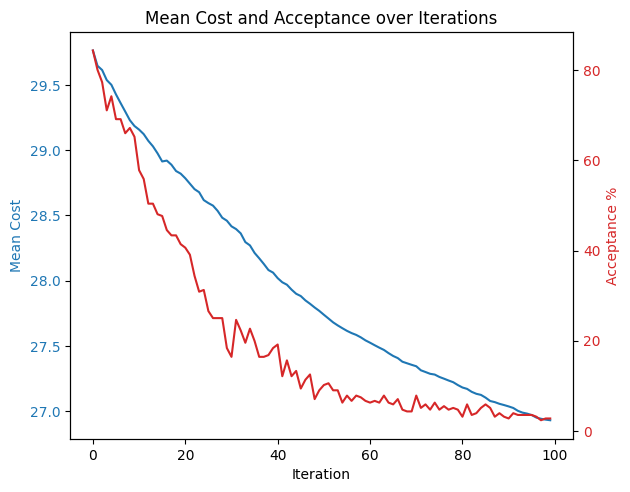

In [3]:
mean = []
accept = []
for cost,acc in zip(costs,acceptance):
    mean.append(torch.mean(cost).item())
    accept.append(torch.sum(acc).item() / len(acc) *100)


import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Mean Cost', color=color)
ax1.plot(mean, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Acceptance %', color=color)
ax2.plot(accept, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Mean Cost and Acceptance over Iterations')
plt.show()